# <u>Supervised Deep Learning</u>

### Prerequisites:
* <a href="../Artificial Neural Networks/Neural Networks.ipynb">Check out the notebook on Neural Networks</a>

## Topics

* [1. Introduction](#perceptron)



In [ ]:
import numpy as np  # for random numbers and numpy arrays
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for 2D Plots


# Neural network classes
import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
#print(sklearn.__version__)

# PyTorch
import torch # main PyTorch library for i.e. multi-dimensional arrays
import torch.nn.functional as F # PyTorch's functional API
import torch.nn as nn # imports PyTorch's neural network module which contains layers and model-building components 
                      # i.e. nn.Linear(10,5) meaning 10 input neurons and 5 output neurons and 
                      # i.e. model = nn.Sequential(
                      #                  nn.Linear(10, 5),  # input -> hidden
                      #                  nn.ReLU(),         # or nn.Sigmoid()
                      #                  nn.Linear(5, 1)    # hidden -> output
                      #      )
import torch.optim as optim # Imports optimization algorithms used during training and ppdates model weights to minimize loss
                            # i.e. optim.SGD(model.parameters(), lr=0.01) or optim.Adam(model.parameters(), lr=0.001)
#print(torch.__version__)

# TensorFlow / Keras (Deep learning framework)
import tensorflow as tf # Imports the main TensorFlow library and provides tensors, automatic differentiation, distributed computing 
                        # and deep learning tools (i.e. x = tf.constant([1, 2, 3]))
from tensorflow import keras # Imports Keras, TensorFlow's high-level deep learning API. It makes building neural networks easier (i.e. model = keras.Sequential())
from tensorflow.keras import layers # Imports common neural network layers used when constructing models (i.e. layers.Dense(64, activation='relu'))
#print(tf.__version__)

from sklearn.datasets import load_iris # Iris dataset
from sklearn.preprocessing import StandardScaler # Standardize features
from sklearn.model_selection import train_test_split # split dataset in train and testset
from sklearn.metrics import accuracy_score # accuracy score

from sklearn.datasets import make_s_curve # create synthetic toy data
from sklearn.datasets import make_moons # create synthetic toy data
from sklearn.datasets import make_circles # create synthetic toy data
from sklearn.datasets import make_classification # create synthetic toy data

print("Setup complete")

Setup complete


<a class="anchor" id="intro"></a>

# 1. Introduction

**Deep learning is based on neural networks with multiple hidden layers.**

**The main challenge in deep learning is usually not making a model complex enough, but preventing it from memorizing the training data (overfitting) while still optimizing efficiently.**

Deep learning aims to learn a function $$f(x,\theta)$$ where 
- $x =$  input
- $\theta = $ all weights and biases
- $f =$ neural network
Training consists of minimizing a loss function $$L(\theta)$$ using gradient descent.

A deep network often has millions or billions of parameters, making it extremely expressive. This expressive power creates two major problems:

1. Overfitting: the model memorizes the training data.
2. Optimization difficulties: training becomes unstable or slow.


<a class="anchor" id="reg"></a>

# 2. Regularization

Regularization means adding constraints that encourage simpler models and  minimize the chances of overfitting to the training data so instead of only minimizing the prediction error, we also penalize large weights. The general objective becomes

$$
\min_\theta \mathcal{R}_\text{reg}(\theta)=\min_\theta  (\mathcal{R}_\text{emp}(\theta) + \lambda J(\theta))
$$ where

- $\mathcal{R}_\text{emp}(\theta)$ is the original loss
- $(\theta)$ is the regularization term
- $\lambda \in [0,\infty)$ is the hyperparameter controlling the regularization strength
- Note: In general we do not penalize the bias

<a class="anchor" id="L2"></a>

### 2.1 L2-Regularization

$$
\min_\theta \mathcal{R}_\text{reg}(\theta)=\min_\theta  (\mathcal{R}_\text{emp}(\theta) + \lambda \frac{1}{2}\lVert \theta \rVert_2^2)
$$ where

- $J(\theta)=\frac{1}{2}\lVert \theta \rVert_2^2$ using the L2-Norm $\lVert \theta \rVert_2$

**Why shrink weights?**
- Large weights make the network highly sensitive
    - Small input changes can lead to large output changes
- Keeping weights small generally produces smoother functions that generalize better

**Gradient**

Without regularization $$\theta^{[t+1]}=\theta^{[t]} - \alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta)$$

With L2 regularization $$\theta^{[t+1]}=\theta^{[t]} - \alpha \underbrace{(\nabla_\theta \mathcal{R}_\text{emp}(\theta) + \lambda \theta^{[t]})}_{\nabla_\theta =\mathcal{R}_\text{reg}(\theta)}$$

The additional term continuously pushes weights toward zero

**Effect**

Instead of eliminating weights entirely, L2 regularization:
- discourages large weights
- spreads information across many parameters
- improves generalization


<a class="anchor" id="WD"></a>

### 2.2 Weight Decay

Weight decay is closely related to L2 regularization.

Instead of adding a penalty to the loss, we directly shrink the weights every update:
$$
\theta^{[t+1]}=(1-\alpha \lambda)\theta^{[t]} - \alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta)
$$


So each iteration consists of:
1. multiply weights by slightly less than 1
2. perform gradient update

### 2.3 L2-Regularization=Weight Decay

For plain (Stochastic) Gradient Descent, L2 regularization and weight decay are mathematically equivalent.
$$
\begin{align*}
\theta^{[t+1]}&=\theta^{[t]} - \alpha (\nabla_\theta \mathcal{R}_\text{emp}(\theta) + \lambda \theta^{[t]}) \\
&=\theta^{[t]}-\alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta) - \alpha \lambda \theta^{[t]} \\
&=\theta^{[t]}- \alpha \lambda \theta^{[t]}-\alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta) \\
&=(1-\alpha \lambda)\theta^{[t]} - \alpha \nabla_\theta \mathcal{R}_\text{emp}(\theta)
\end{align*}
$$

For adaptive optimizers like Adam, they are not equivalent, which is why optimizers such as AdamW explicitly implement weight decay.

<a class="anchor" id="ex1"></a>

### 2.4 Example 1: Effect of regularization strength $\lambda$ on weights 

$$
y = \tau(W^{(2)}\sigma(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/92_.jpeg" width="550"/>
</div>


- $W^{(1)} \in \mathbb{R}^{10 \times 2}$
- $b^{(1)} \in \mathbb{R}^{10}$
- $X \in \mathbb{R}^{N \times 2}$
- $W^{(2)} \in \mathbb{R}^{1 \times 10}$
- $b^{(2)} \in \mathbb{R}^{1}$
- $\sigma(x)=\text{ReLU}(x)=\max(0,x)$
- $\tau(x)=\text{sigmoid}(x)=\frac{1}{1+\exp(-x)}$
- $\lambda \in \{0,0.001,0.005,0.01\}$ Regularization strength

##### Forward propagation
- $Z^{(0)}=X=\begin{bmatrix}x_1^\top  \\ x_2^\top \\ \vdots \\ x_N^\top \end{bmatrix}$
- $A^{(1)}=\underbrace{Z^{(0)}(W^{(1)})^\top}_{(N \times 2)(2 \times 10)=(N \times 10)} + \underbrace{1_N(b^{(1)})^\top}_{N \times 10} \in \mathbb{R}^{N \times 10}$
- $Z^{(1)}=\sigma(A^{(1)})=\text{ReLU}(A^{(1)}) \in \mathbb{R}^{N \times 10}$
- $A^{(2)}=\underbrace{Z^{(1)}(W^{(2)})^\top}_{(N \times 10)(10 \times 1)=(N \times 1)} + \underbrace{1_Nb^{(2)}}_{N \times 1} \in \mathbb{R}^{N \times 1}$
- $Z^{(2)}=\tau(A^{(2)})=\text{sigmoid}(A^{(2)}) \in \mathbb{R}^{N \times 1}$
- $Y=Z^{(2)}$
- Binary Cross-Entropy loss $\mathcal{R}_\text{emp}(\ldots)=L(Y,T)=-\frac{1}{N} \sum_{i=1}^N \left[T_i \log(Y_i) + (1-T_i)\log(1-Y_i)\right]$ with $T \in \mathbb{R}^{N \times 1}$


##### Backward propagation with L2 Regularization

Our Regularized Loss is 
$$
\mathcal{R}_\text{reg}(\ldots) = \mathcal{R}_\text{emp}(\ldots) + \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2)
$$
and typically we do not regularize biases.

$$
\begin{align*}
\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(2)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial b^{(2)}} \\

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(2)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial W^{(2)}} \frac{\partial }{\partial W^{(2)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\


\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(1)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\frac{\partial A^{(1)}}{\partial b^{(1)}} \\


\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(1)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\frac{\partial A^{(1)}}{\partial W^{(1)}} \frac{\partial }{\partial W^{(1)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\
\end{align*}
$$
---
$$
\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}} = 1
$$


$$
\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}=\frac{1}{N}\left(-\frac{T}{Y} + \frac{1-T}{1-Y}\right)
$$

$$
\begin{align*}
\frac{\partial Y}{\partial A^{(2)}}
&=\frac{\partial}{\partial A^{(2)}} \tau(A^{(2)})\\
&=\frac{\partial}{\partial A^{(2)}} \frac{1}{1+\exp(-A^{(2)})} \\
&=\frac{\partial}{\partial A^{(2)}} (1+\exp(-A^{(2)}))^{-1} \\
&= -(1+\exp(-A^{(2)}))^{-2}\frac{\partial}{\partial A^{(2)}}(1+\exp(-A^{(2)}))  \\
&= -(1+\exp(-A^{(2)}))^{-2}(-\exp(-A^{(2)}))  \\
&= \frac{\exp(-A^{(2)})}{(1+\exp(-A^{(2)}))^2} \hspace{1 mm} \mid \hspace{1 mm} Y=\frac{1}{1+\exp(-A^{(2)})}, 1-Y=\frac{\exp(-A^{(2)})}{1+\exp(-A^{(2)})} \\
&= Y \odot (1-Y)
\end{align*}
$$

---

$$
\begin{align*}
\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(2)}}&= \underbrace{\left(\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\right)}_{:=\delta^{(2)}=\frac{1}{N}(Y-T)}\frac{\partial A^{(2)}}{\partial b^{(2)}}\\ &= 1 \cdot 1 \cdot \frac{1}{N} \left(-\frac{T}{Y}+\frac{1-T}{1-Y}\right) \cdot Y \odot (1-Y) \cdot 1 = \frac{1}{N}1_N^\top (Y - T) \\

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(2)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial W^{(2)}} \frac{\partial }{\partial W^{(2)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\ &=(\delta^{(2)})^\top Z^{(1)} + \lambda W^{(2)} \\


\frac{\partial \mathcal{R}_\text{reg}}{\partial b^{(1)}}
&=\underbrace{\left(\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\right)}_{:=\delta^{(1)}}\frac{\partial A^{(1)}}{\partial b^{(1)}} \\ 
&=\underbrace{\left(\delta^{(2)}W^{(2)} \odot \frac{\partial}{\partial A^{(1)}}\text{ReLU}(A^{(1)})\right)}_{\delta^{(1)} \text{ of shape } N \times 10} \odot 1_N \\ 
&=1_N^\top \delta^{(1)} \quad \mid \quad

\left[\frac{\partial}{\partial A^{(1)}}\text{ReLU}(A^{(1)})\right]_{ij}=\begin{cases} 1 &, A_{ij}^{(1)} > 0 \\ 0 &, A_{ij}^{(1)} \leq 0  \end{cases}
\\

\frac{\partial \mathcal{R}_\text{reg}}{\partial W^{(1)}}&=\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{reg}}\frac{\partial \mathcal{R}_\text{reg}}{\partial \mathcal{R}_\text{emp}}\frac{\partial \mathcal{R}_\text{emp}}{\partial Y}\frac{\partial Y}{\partial A^{(2)}}\frac{\partial A^{(2)}}{\partial Z^{(1)}}\frac{\partial Z^{(1)}}{\partial A^{(1)}}\frac{\partial A^{(1)}}{\partial W^{(1)}} \frac{\partial }{\partial W^{(1)}} \frac{\lambda }{2}(\lVert W^{(1)}\rVert_F^2 + \lVert W^{(2)}\rVert_F^2) \\ &=(\delta^{(1)})^\top X + \lambda W^{(1)} \\
\end{align*}
$$



In [ ]:
def initialize(seed=2008,input_dim=2,output_dim=1,hidden_sizes=[10]):
    """ 
    Generic initialization for a fully connected neural network. 
    Example: 
        input_dim=2 
        hidden_sizes=[10] 
        output_dim=1 => 2 -> 10 -> 1 
    """

    rng = np.random.default_rng(seed)

    layer_sizes = [input_dim] + hidden_sizes + [output_dim]

    params = {}

    for l in range(1, len(layer_sizes)):

        fan_in = layer_sizes[l - 1]
        fan_out = layer_sizes[l]

        # He initialization for ReLU layers
        params[f"W{l}"] = (rng.standard_normal((fan_out, fan_in))* np.sqrt(2 / fan_in))

        # biases stored as row vectors
        params[f"b{l}"] = np.zeros((1, fan_out))

    return params


# Activations
def ReLU(x):
    return np.maximum(0, x)


def dReLU(x):
    return (x > 0).astype(float)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Loss
def Loss(Y, T):
    eps = 1e-12
    Y = np.clip(Y, eps, 1 - eps) # avoid logarithm of 0
    N = len(Y)
    return -np.sum(T * np.log(Y)+ (1 - T) * np.log(1 - Y)) / N


def RegularizedLoss(params, Y, T, lbda):

    loss = Loss(Y, T)
    reg = (np.sum(params["W1"]**2)+ np.sum(params["W2"]**2))
    return loss + 0.5 * lbda * reg


# Forward propagation
def forward(params, X):

    # Layer 1
    A1 = X @ params["W1"].T + params["b1"]
    Z1 = ReLU(A1)

    # Output layer
    A2 = Z1 @ params["W2"].T + params["b2"]
    Y = sigmoid(A2)

    cache = {"A1": A1,"Z1": Z1,"A2": A2,"Y": Y}
    return cache


# Backpropagation
def backward(params, X, T, lbda):

    N = X.shape[0]
    cache = forward(params, X)

    A1 = cache["A1"]
    Z1 = cache["Z1"]
    Y = cache["Y"]


    # Output layer
    # delta^(2) = (Y-T)/N
    delta2 = (Y - T) / N

    dW2 = delta2.T @ Z1 + lbda * params["W2"]
    db2 = np.sum(delta2, axis=0, keepdims=True)


    # Hidden layer
    delta1 = (delta2 @ params["W2"]) * dReLU(A1)
    dW1 = delta1.T @ X + lbda * params["W1"]
    db1 = np.sum(delta1, axis=0, keepdims=True)

    grads = {"dW1": dW1,"db1": db1,"dW2": dW2,"db2": db2}
    return grads


# Parameter update
def update(params, grads, learning_rate):
    params["W1"] -= learning_rate * grads["dW1"]
    params["b1"] -= learning_rate * grads["db1"]
    params["W2"] -= learning_rate * grads["dW2"]
    params["b2"] -= learning_rate * grads["db2"]
    return params


# Prediction
def predict(params, X):
    Y = forward(params, X)["Y"]
    return (Y >= 0.5).astype(int)


# Accuracy
def accuracy(params, X, T):
    pred = predict(params, X)
    return np.mean(pred == T)


# Training loop
def train(X,T,hidden_sizes=[10],learning_rate=0.01,lbda=0.0,epochs=1000,seed=2008,verbose=True):

    params = initialize(seed=seed,input_dim=X.shape[1],output_dim=1,hidden_sizes=hidden_sizes)

    losses = []

    for epoch in range(epochs):

        grads = backward(params, X, T, lbda)
        params = update(params,grads,learning_rate)

        if epoch % 50 == 0 or epoch == epochs - 1:
            Y = forward(params, X)["Y"]
            loss = RegularizedLoss(params,Y,T,lbda)
            losses.append(loss)
            if verbose:
                print(f"Epoch {epoch:4d} | "f"Loss = {loss:.6f}")

    return params, losses

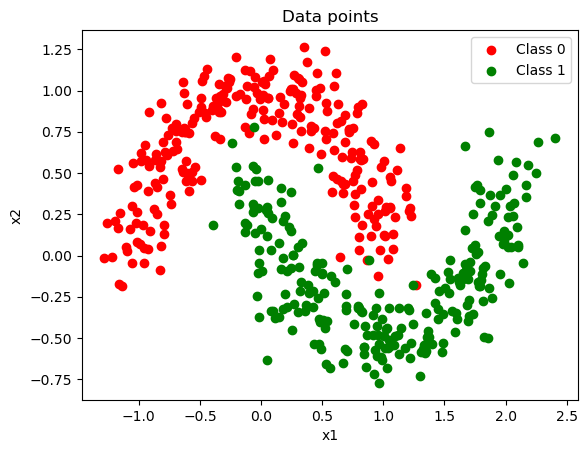

In [43]:
X, y = make_moons(n_samples=500,noise=0.15,random_state=1128)
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")
plt.scatter(X[:,0][y==0],X[:,1][y==0],label="Class 0",c="red")
plt.scatter(X[:,0][y==1],X[:,1][y==1],label="Class 1",c="green")
plt.title("Data points")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

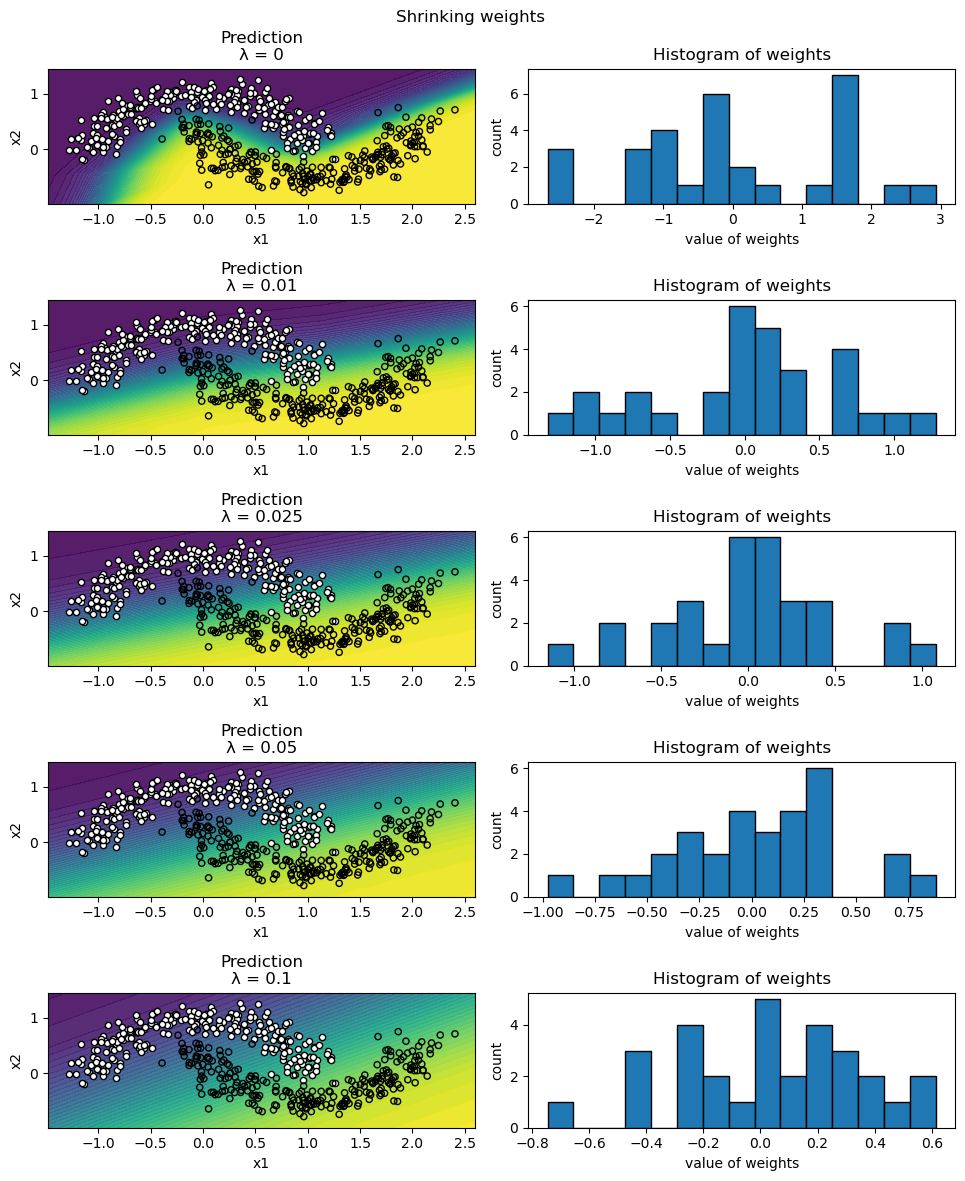

In [53]:
def plot_decision_boundary(ax, params, X, y):

    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))

    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = forward(params, grid)["Y"]
    probs = probs.reshape(xx.shape)

    ax.contourf(xx,yy,probs,levels=50,cmap="viridis",alpha=0.9)
    ax.scatter(X[y == 0, 0],X[y == 0, 1],edgecolor="black",facecolor="white",s=20)
    ax.scatter(X[y == 1, 0],X[y == 1, 1],edgecolor="black",facecolor="none",s=20)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


lambdas = [0, 0.010, 0.025, 0.05, 0.1]
results = {}

for lbda in lambdas:

    params, losses = train(X,y.reshape(-1,1),hidden_sizes=[10],learning_rate=0.05,lbda=lbda,epochs=5000,verbose=False)
    results[lbda] = params

fig, axes = plt.subplots(len(lambdas),2,figsize=(10, 12))

for i, lbda in enumerate(lambdas):

    params = results[lbda]

    # Decision boundary
    ax = axes[i, 0]
    plot_decision_boundary(ax,params,X,y)
    ax.set_title(f"Prediction\nλ = {lbda}")

    # Histogram of weights
    weights = np.concatenate([params["W1"].ravel(),params["W2"].ravel()])

    ax = axes[i, 1]

    ax.hist(weights,bins=15,edgecolor="black")
    ax.set_title("Histogram of weights")
    ax.set_xlabel("value of weights")
    ax.set_ylabel("count")
    fig.suptitle("Shrinking weights")

plt.tight_layout()
plt.show()

<a class="anchor" id="ex1"></a>

### 2.4 Example 2: Structual Risk Minimization 
